Dataset: /Users/sumankar/.cache/kagglehub/datasets/debeshjha1/kvasirseg/versions/3
Images: 1000
Masks : 1000

Selected Sample:
/Users/sumankar/.cache/kagglehub/datasets/debeshjha1/kvasirseg/versions/3/Kvasir-SEG/Kvasir-SEG/images/cju8alhigqn2h0801zksudldd.jpg

SCRIBBLE STATS
Foreground Scribble Pixels: 459
Background Supervision: 500
Ignored Pixels: 323233
Supervised % : 0.30%


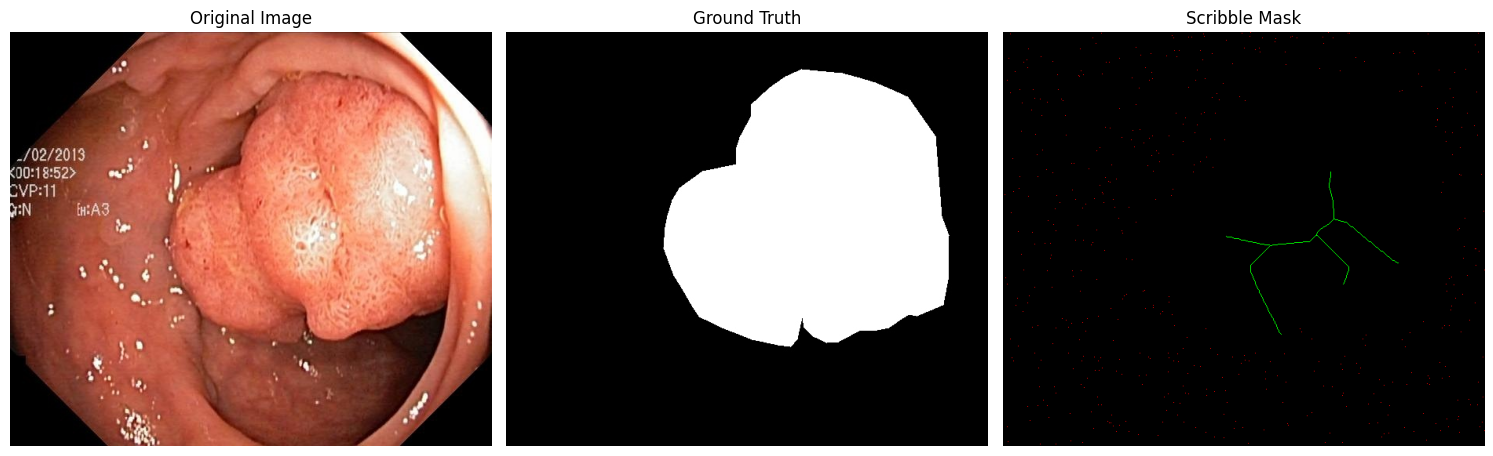

In [5]:

import sys
import subprocess
from utils.weak_utils import create_scribble_mask

def install(pkg):
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", pkg]
    )

try:
    import kagglehub
except:
    install("kagglehub")

try:
    from skimage.morphology import skeletonize
except:
    install("scikit-image")

import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub



print("Downloading Kvasir-SEG...")
dataset_path = kagglehub.dataset_download( "debeshjha1/kvasirseg")
print("Dataset:", dataset_path)
image_paths = sorted( glob.glob( os.path.join(
            dataset_path,
            "**",
            "images",
            "*.*"
        ),
        recursive=True
    )
)

mask_paths = sorted(glob.glob(os.path.join(
            dataset_path,
            "**",
            "masks",
            "*.*"
        ),
        recursive=True
    )
)

print("Images:", len(image_paths))
print("Masks :", len(mask_paths))


idx = random.randint(0,len(image_paths)-1)
image_path = image_paths[idx]
mask_path = mask_paths[idx]

print("\nSelected Sample:")
print(image_path)

image = Image.open(image_path).convert("RGB")
gt_mask = Image.open(mask_path).convert("L")
image_np = np.array(image)
gt_np = np.array(gt_mask)
scribble_np = np.array(create_scribble_mask(gt_mask))
fg_pixels = np.sum(scribble_np == 1)
bg_pixels = np.sum(scribble_np == 0)
ignore_pixels = np.sum(scribble_np == 255)
total_pixels = scribble_np.size

print("\nSCRIBBLE STATS")
print(f"Foreground Scribble Pixels: {fg_pixels}")
print(f"Background Supervision: {bg_pixels}")
print(f"Ignored Pixels: {ignore_pixels}")
print( f"Supervised % : " f"{100*(fg_pixels+bg_pixels)/total_pixels:.2f}%")

scribble_vis = np.zeros((scribble_np.shape[0],scribble_np.shape[1],3),dtype=np.uint8)
scribble_vis[  scribble_np == 0] = [255,0,0]
scribble_vis[scribble_np == 1] = [0,255,0]


plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,4,2)
plt.imshow(gt_np,cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(scribble_vis)
plt.title("Scribble Mask")
plt.axis("off")
plt.tight_layout()
plt.show()